## slope data


In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
slope = gpd.read_file("/fs9/eliviau/hex2vec_project/clean_data/data/slope_tags") #specify which tags to use


In [2]:
slope.head()

,feature_id,slope,geometry
0,0,3.0,"POLYGON ((154.41066 49.81648, 154.42088 49.816..."
1,1,5.0,"POLYGON ((154.42088 49.81648, 154.4311 49.8164..."
2,2,5.0,"POLYGON ((154.4311 49.81648, 154.44131 49.8164..."
3,3,4.0,"POLYGON ((154.44131 49.81648, 154.45153 49.816..."
4,4,2.0,"POLYGON ((154.45153 49.81648, 154.46174 49.816..."


In [3]:
slope["slope"].unique()

array([ 3.,  5.,  4.,  2.,  1.,  7., 10.,  9.,  8.,  6.,  0., 13., 12.,
       11., -4., 15., 14., 16., 17., 20., 18.])

In [4]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [6]:
#check if slope is in the same crs as area
slope.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872ef2829ffffff,"POLYGON ((141.07493 45.32082, 141.07057 45.332..."
872e1bc51ffffff,"POLYGON ((141.52688 42.88309, 141.52274 42.895..."
872e1bb35ffffff,"POLYGON ((141.10135 42.42525, 141.09718 42.437..."
872ee6136ffffff,"POLYGON ((140.11679 42.48164, 140.11248 42.493..."
872ead544ffffff,"POLYGON ((144.16342 43.68556, 144.1596 43.698,..."


In [8]:
regions.shape

(28902, 1)

step 3 : join 

In [9]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
slope = slope.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, slope)

# Preview the result
joined.head()


,
region_id,feature_id
872e8db61ffffff,3244
872e8db6cffffff,3244
872e8db6effffff,3244
872e8db61ffffff,3245
872e8db6cffffff,3245


In [10]:
joined.shape

(199022, 0)

In [11]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    slope[["feature_id", "slope"]],
    on="feature_id",
    how="left"
)

In [12]:
joined_with_tags.head()

,region_id,feature_id,slope
0,872e8db61ffffff,3244,0.0
1,872e8db6cffffff,3244,0.0
2,872e8db6effffff,3244,0.0
3,872e8db61ffffff,3245,0.0
4,872e8db6cffffff,3245,0.0


In [13]:
ahp_slope_scores = {
    0: 10,
    1: 10,
    2: 10,
    3: 7,
    4: 6,
    5: 5,
    6: 4,
    7: 3,
    8: 2,
    9: 2,
    10: 0,
    11: 0,
    12: 0,
    13: 0,
    14: 0,
    15: 0,
    16: 0,
    17: 0,
    18: 0,
    19: 0,
    20: 0,
    -4: 0,  
}



In [14]:
joined_with_tags["slope_score"] = joined_with_tags["slope"].map(ahp_slope_scores)


In [15]:
hex_scores = joined_with_tags.groupby("region_id")["slope_score"].mean().reset_index()
hex_scores.columns = ["region_id", "slope_score"]


In [16]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [17]:
regions_scored.head(30)

,region_id,geometry,slope_score
0,872ef2829ffffff,"POLYGON ((141.07493 45.32082, 141.07057 45.332...",8.333333
1,872e1bc51ffffff,"POLYGON ((141.52688 42.88309, 141.52274 42.895...",10.000000
2,872e1bb35ffffff,"POLYGON ((141.10135 42.42525, 141.09718 42.437...",10.000000
3,872ee6136ffffff,"POLYGON ((140.11679 42.48164, 140.11248 42.493...",10.000000
4,872ead544ffffff,"POLYGON ((144.16342 43.68556, 144.1596 43.698,...",10.000000
5,872ea9c82ffffff,"POLYGON ((143.50927 44.41916, 143.50531 44.431...",0.000000
6,872e19c0effffff,"POLYGON ((141.30023 41.83727, 141.29611 41.849...",0.000000
7,872ef682effffff,"POLYGON ((142.12923 44.60547, 142.12506 44.617...",10.000000
8,872e1e185ffffff,"POLYGON ((143.67156 42.46805, 143.66774 42.480...",0.000000
9,872e1e8c4ffffff,"POLYGON ((143.58607 42.17082, 143.58225 42.183...",0.000000


In [21]:
#regions_scored save to output *before creating the map 
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_slopereso7.geojson", driver="GeoJSON")

In [19]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "slope_score", colormap="YlGnBu", opacity=0.6)
m.save("slope_Hokkaido_map.html")


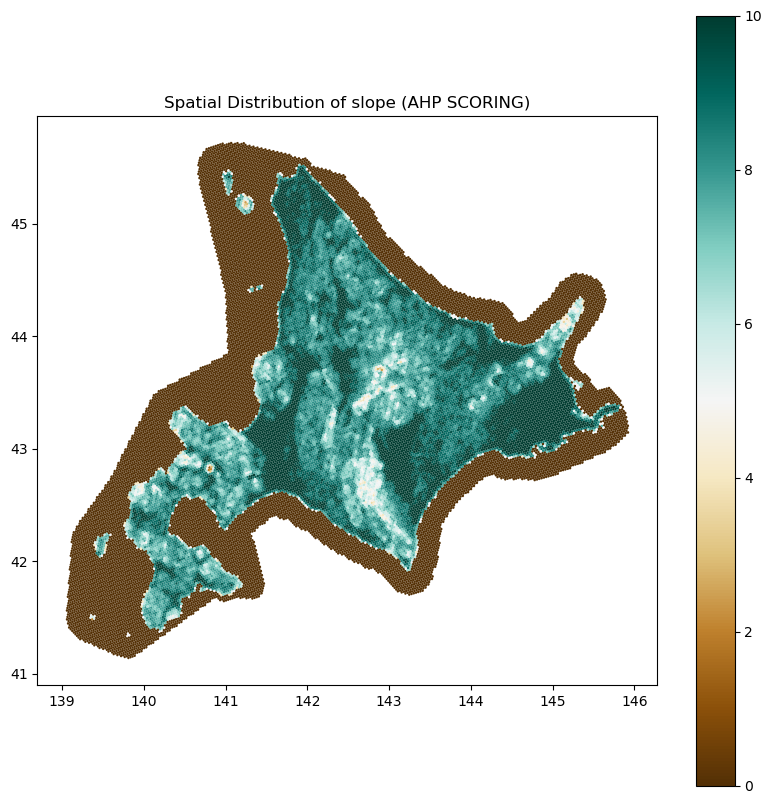

In [25]:
#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='slope_score',
    cmap='BrBG',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of slope (AHP SCORING)")
plt.show()


/tmp/ipykernel_49521/2607490917.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


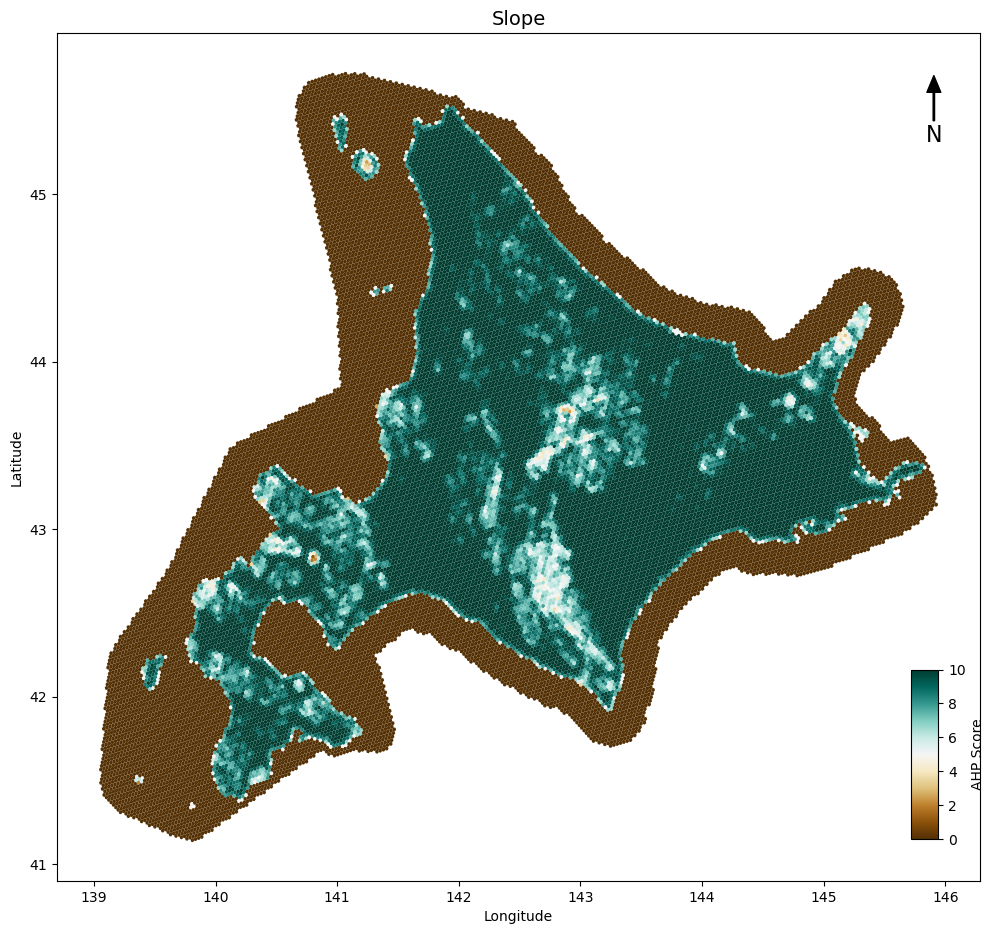

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='slope_score',
    cmap='BrBG',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='BrBG', norm=plt.Normalize(vmin=regions_scored['slope_score'].min(), vmax=regions_scored['slope_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Slope", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()


In [26]:
regions_scored.head()

,geometry,slope_score
region_id,,
872eac84dffffff,"POLYGON ((145.21163 43.36088, 145.20798 43.373...",10.000000
872ea9336ffffff,"POLYGON ((142.61815 44.18347, 142.61408 44.195...",7.692308
872ea9ac6ffffff,"POLYGON ((142.48712 44.03528, 142.48303 44.047...",8.363636
872ef6a92ffffff,"POLYGON ((141.71553 44.88371, 141.71129 44.895...",0.000000
872e19492ffffff,"POLYGON ((141.22082 42.41407, 141.21666 42.426...",0.000000


In [ ]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/land_use_framework/data/hokkaido_ahp_slopereso7.geojson", driver="GeoJSON")